<div align="center">

# **BÁO CÁO DỰ ÁN**

## AIN501

## Các model cho bài toán phát hiện hư hỏng mặt đường
*Cải tiến kiến trúc mô hình phát hiện đối tượng cho bài toán nhận diện hư hỏng mặt đường (ổ gà, vết nứt, nắp cống)*

</div>

---

<div align="center">
</br>

| STT | Thành viên | MSHV |
|:---:|:---|:---|
| 1 | Nguyễn Văn Tú | 25MS33068 |
| 2 | Bùi Ngọc Bảo Trân | 25MS33062 |
| 3 | Nguyễn Anh Việt | 25MS33082 |

</br>

**Học phần / Dự án:** Deep Learning — Phát hiện hư hỏng mặt đường </br>
**Ngày báo cáo:** Tháng 9, 2026

</div>


<a id="muc-luc"></a>
## Mục lục

- [Giới thiệu](#gioi-thieu)
- [0. Cấu hình dùng chung cho tất cả thí nghiệm](#sec0)
  - [Hàm tiện ích dùng chung: benchmark latency & lưu kết quả](#sec0-1)
- [1. Model Baseline — YOLO11s-P2 (không chỉnh sửa)](#sec1)
  - [1.1. Load và kiểm tra kiến trúc model](#sec1-1)
  - [1.2. Huấn luyện Baseline (100 epochs, patience=20)](#sec1-2)
  - [1.3. Đánh giá trên tập validation](#sec1-3)
  - [1.4. Benchmark tốc độ suy luận (latency/FPS)](#sec1-4)
  - [1.5. Tổng hợp kết quả Baseline](#sec1-5)
- [2. Model + ECA (Efficient Channel Attention)](#sec2)
  - [2.1. Định nghĩa module ECA](#sec2-1)
  - [2.2. Gắn ECA vào các layer neck của YOLO11s-P2](#sec2-2)
  - [2.3. Kiểm tra tích hợp (forward pass & gradient flow)](#sec2-3)
  - [2.4. Load lại pretrained weight (backbone) + ECA (khởi tạo mới)](#sec2-4)
  - [2.5. Huấn luyện model + ECA](#sec2-5)
  - [2.6. Đánh giá, benchmark & lưu kết quả](#sec2-6)
- [3. Model + Mish Activation ⭐ (Model tốt nhất)](#sec3)
  - [3.1. Định nghĩa hàm kích hoạt Mish](#sec3-1)
  - [3.2. Thay thế SiLU → Mish ở neck/head](#sec3-2)
  - [3.3. Kiểm tra model (tham số, forward pass, gradient flow)](#sec3-3)
  - [3.4. Huấn luyện model + Mish](#sec3-4)
  - [3.5. Đánh giá, benchmark & lưu kết quả](#sec3-5)
- [4. Model + ECA + Mish (Ablation kết hợp)](#sec4)
  - [4.1. Định nghĩa module ECA và Mish](#sec4-1)
  - [4.2. Áp dụng đồng thời Mish (neck/head) và ECA (layer 16, 19, 22)](#sec4-2)
  - [4.3. Kiểm tra forward pass & gradient](#sec4-3)
  - [4.4. Huấn luyện model + ECA + Mish](#sec4-4)
  - [4.5. Đánh giá, benchmark & lưu kết quả](#sec4-5)
- [5. Model + RMSA (Residual Multi-Scale Attention)](#sec5)
  - [5.1. Định nghĩa module RMSA (gồm ECA lồng bên trong)](#sec5-1)
  - [5.2. Thay thế C3k2 ở layer 16, 19 bằng RMSA](#sec5-2)
  - [5.3. Kiểm tra tích hợp (số tham số, forward pass, gradient)](#sec5-3)
  - [5.4. Huấn luyện model + RMSA](#sec5-4)
  - [5.5. Đánh giá, benchmark & lưu kết quả](#sec5-5)
- [6. So sánh tất cả các Model](#sec6)
  - [6.1. Load kết quả của cả 5 model](#sec6-1)
  - [6.2. Bảng so sánh chính](#sec6-2)
  - [6.3. Bảng Ablation (tác động của từng thành phần)](#sec6-3)
  - [6.4. Biểu đồ so sánh trực quan](#sec6-4)
  - [6.5. So sánh AP theo từng lớp (Pothole / Crack / Manhole)](#sec6-5)
  - [6.6. Trả lời các câu hỏi thực nghiệm dựa trên số liệu](#sec6-6)
  - [6.7. Kết luận cuối cùng (từ notebook gốc)](#sec6-7)
- [7. Kết luận tổng thể](#sec7)
  - [Bảng tổng hợp cuối cùng](#sec7-1)
  - [Nhận định dựa trên số liệu thực nghiệm](#sec7-2)
  - [Kết luận](#sec7-3)

---


<a id="gioi-thieu"></a>
## Giới thiệu

### Mục tiêu

Báo cáo này tổng hợp lại toàn bộ quá trình thực nghiệm của nhóm nhằm tìm kiến trúc cải tiến tốt nhất cho **YOLO11s-P2** trong bài toán phát hiện hư hỏng mặt đường (ổ gà, vết nứt, nắp cống). Nhóm đã huấn luyện và đánh giá **5 phương án kiến trúc** trên cùng một bộ dữ liệu, cùng cấu hình huấn luyện, nhằm đảm bảo tính công bằng khi so sánh.

### Nguồn dữ liệu tổng hợp

Toàn bộ code và output thực tế trong báo cáo được tổng hợp từ 6 notebook thí nghiệm gốc mà nhóm đã thực hiện:

| # | File gốc | Mô tả |
|---|----------|-------|
| 01 | `01_yolo11s_p2_baseline.ipynb` | Baseline — YOLO11s-P2 không chỉnh sửa |
| 02 | `02_yolo11s_p2_eca.ipynb` | + ECA (Efficient Channel Attention) |
| 03 | `03_yolo11s_p2_mish.ipynb` | + Mish activation (**model tốt nhất**) |
| 04 | `04_yolo11s_p2_eca_mish.ipynb` | + ECA + Mish (ablation kết hợp) |
| 05 | `05_yolo11s_p2_rmsa.ipynb` | + RMSA (Residual Multi-Scale Attention) |
| 06 | `06_compare_all_models.ipynb` | So sánh tổng hợp cả 5 mô hình |

### Cấu trúc báo cáo

1. **Cấu hình dùng chung** cho tất cả thí nghiệm (seed, hyperparameter, hàm benchmark/lưu kết quả)
2. **Model Baseline**
3. **Các model cải tiến:** ECA → Mish → ECA+Mish → RMSA
4. **So sánh tất cả model** & kết luận model tốt nhất

[⬆️ Về Mục lục](#muc-luc)

---


<a id="sec0"></a>
## 0. Cấu hình dùng chung cho tất cả thí nghiệm

Cả 5 model (baseline, ECA, Mish, ECA+Mish, RMSA) đều được huấn luyện với **cùng một seed, cùng hyperparameter, cùng dataset** để đảm bảo so sánh công bằng. Các cell dưới đây được lấy từ `01_yolo11s_p2_baseline.ipynb` (cell môi trường & cấu hình train giống hệt nhau ở cả 5 notebook).

In [1]:
import sys
import torch
import platform

print("=" * 60)
print("ENVIRONMENT CHECK")
print("=" * 60)
print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")

import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    DEVICE = 0
    print(f"Current device: cuda:0")
else:
    print("CUDA NOT AVAILABLE - Training will proceed on CPU")
    print(f"Reason: PyTorch build = {torch.__version__} (CPU-only build)")
    DEVICE = "cpu"
    print(f"Current device: cpu")
print(f"OS: {platform.system()} {platform.release()}")
print("=" * 60)


ENVIRONMENT CHECK
Python version: 3.13.6 (tags/v3.13.6:4e66535, Aug  6 2025, 14:36:00) [MSC v.1944 64 bit (AMD64)]
PyTorch version: 2.11.0+cu128
Ultralytics version: 8.4.92


CUDA available: True
CUDA version: 12.8
GPU name: NVIDIA GeForce RTX 3060 Laptop GPU
GPU memory: 6.00 GB
Current device: cuda:0
OS: Windows 11


In [2]:
# Shared training configuration - MUST be identical for all 5 models
import os, json, random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

TRAIN_CONFIG = {
    "data": r"D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\dataset\data.yaml",
    "imgsz": 640,
    "epochs": 100,
    "patience": 20,
    "batch": 8,
    "device": "cuda",
    "workers": 0,  # Windows safety
    "seed": SEED,
    "deterministic": True,
    "amp": True,  # AMP only with CUDA
    "pretrained": True,
    "optimizer": "auto",
    "lr0": 0.01,
    "lrf": 0.01,
    "momentum": 0.937,
    "weight_decay": 0.0005,
    "warmup_epochs": 3.0,
    "warmup_momentum": 0.8,
    "warmup_bias_lr": 0.1,
    "box": 7.5,
    "cls": 0.5,
    "dfl": 1.5,
    "hsv_h": 0.015,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "degrees": 0.0,
    "translate": 0.1,
    "scale": 0.5,
    "shear": 0.0,
    "perspective": 0.0,
    "flipud": 0.0,
    "fliplr": 0.5,
    "mosaic": 1.0,
    "mixup": 0.0,
    "copy_paste": 0.0,
    "verbose": True,
}

RESULTS_DIR = r"D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Training configuration loaded:")
for k, v in TRAIN_CONFIG.items():
    if k != "data":
        print(f"  {k}: {v}")


Training configuration loaded:
  imgsz: 640
  epochs: 100
  patience: 20
  batch: 8
  device: cuda
  workers: 0
  seed: 42
  deterministic: True
  amp: True
  pretrained: True
  optimizer: auto
  lr0: 0.01
  lrf: 0.01
  momentum: 0.937
  weight_decay: 0.0005
  warmup_epochs: 3.0
  warmup_momentum: 0.8
  warmup_bias_lr: 0.1
  box: 7.5
  cls: 0.5
  dfl: 1.5
  hsv_h: 0.015
  hsv_s: 0.7
  hsv_v: 0.4
  degrees: 0.0
  translate: 0.1
  scale: 0.5
  shear: 0.0
  perspective: 0.0
  flipud: 0.0
  fliplr: 0.5
  mosaic: 1.0
  mixup: 0.0
  copy_paste: 0.0
  verbose: True


<a id="sec0-1"></a>
### Hàm tiện ích dùng chung: benchmark latency & lưu kết quả

Hai hàm `benchmark_model()` (đo latency/FPS có kiểm soát) và `save_experiment_results()` (trích xuất metric, lưu JSON để notebook so sánh dùng lại) được định nghĩa giống hệt nhau ở cả 5 notebook huấn luyện.

In [3]:
def benchmark_model(model_path, device, imgsz=640, warmup=20, runs=100):
    """Controlled latency benchmark for a YOLO model."""
    import time
    from ultralytics import YOLO
    
    model = YOLO(model_path)
    
    # Create dummy input
    dummy = torch.randn(1, 3, imgsz, imgsz)
    if device != "cpu":
        dummy = dummy.to(f"cuda:{device}")
    
    # Warmup
    print(f"Warming up ({warmup} iterations)...")
    for _ in range(warmup):
        _ = model.predict(source=dummy, verbose=False, device=device)
    
    # Timed runs
    print(f"Benchmarking ({runs} iterations)...")
    latencies = []
    for _ in range(runs):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.perf_counter()
        _ = model.predict(source=dummy, verbose=False, device=device)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        end = time.perf_counter()
        latencies.append((end - start) * 1000)  # ms
    
    mean_lat = np.mean(latencies)
    std_lat = np.std(latencies)
    fps = 1000.0 / mean_lat
    
    print(f"Latency: {mean_lat:.2f} +/- {std_lat:.2f} ms")
    print(f"FPS: {fps:.1f}")
    
    del model
    import gc; gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return mean_lat, std_lat, fps


In [4]:
def save_experiment_results(model_name, results, model_path, benchmark_results, results_dir):
    """Save experiment results to JSON for comparison notebook."""
    import os, json
    
    mean_lat, std_lat, fps = benchmark_results
    
    # Get model file size
    model_size_bytes = os.path.getsize(model_path)
    model_size_mb = model_size_bytes / (1024 * 1024)
    
    # Get model info
    from ultralytics import YOLO
    model = YOLO(model_path)
    info = model.info()
    if isinstance(info, tuple) and len(info) >= 4:
        n_layers, n_params, n_grads, gflops = info[:4]
    else:
        n_layers = len(list(model.model.modules()))
        n_params = sum(p.numel() for p in model.model.parameters())
        n_grads = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
        gflops = 0.0
    
    # Extract metrics from results
    metrics = {}
    if hasattr(results, 'results_dict'):
        rd = results.results_dict
        metrics["precision"] = rd.get("metrics/precision(B)", 0)
        metrics["recall"] = rd.get("metrics/recall(B)", 0)
        metrics["mAP50"] = rd.get("metrics/mAP50(B)", 0)
        metrics["mAP50-95"] = rd.get("metrics/mAP50-95(B)", 0)
    
    # Per-class metrics if available
    per_class = {}
    if hasattr(results, 'box'):
        box = results.box
        if hasattr(box, 'ap50') and box.ap50 is not None:
            class_names = {0: "Pothole", 1: "Crack", 2: "Manhole"}
            for i, name in class_names.items():
                if i < len(box.ap50):
                    per_class[name] = {
                        "AP50": float(box.ap50[i]),
                        "AP50-95": float(box.ap[i]) if hasattr(box, 'ap') and i < len(box.ap) else 0,
                        "precision": float(box.p[i]) if hasattr(box, 'p') and i < len(box.p) else 0,
                        "recall": float(box.r[i]) if hasattr(box, 'r') and i < len(box.r) else 0,
                    }
    
    result_data = {
        "model_name": model_name,
        "model_path": model_path,
        "n_layers": int(n_layers),
        "n_params": int(n_params),
        "n_grads": int(n_grads),
        "gflops": float(gflops),
        "model_size_mb": float(model_size_mb),
        "precision": float(metrics.get("precision", 0)),
        "recall": float(metrics.get("recall", 0)),
        "mAP50": float(metrics.get("mAP50", 0)),
        "mAP50-95": float(metrics.get("mAP50-95", 0)),
        "latency_ms": float(mean_lat),
        "latency_std_ms": float(std_lat),
        "fps": float(fps),
        "per_class": per_class,
    }
    
    output_path = os.path.join(results_dir, f"{model_name}_metrics.json")
    with open(output_path, "w") as f:
        json.dump(result_data, f, indent=2)
    print(f"Results saved to {output_path}")
    
    del model
    import gc; gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return result_data


[⬆️ Về Mục lục](#muc-luc)

---
<a id="sec1"></a>
## 1. Model Baseline — YOLO11s-P2 (không chỉnh sửa)

**Nguồn:** `01_yolo11s_p2_baseline.ipynb`

Model gốc YOLO11s với thêm detection scale P2 (stride=4), giúp phát hiện tốt hơn các vật thể nhỏ (vết nứt, ổ gà nhỏ). Đây là điểm mốc (baseline) để so sánh hiệu quả của các cải tiến kiến trúc ở phần sau.

<a id="sec1-1"></a>
### 1.1. Load và kiểm tra kiến trúc model

In [5]:
from ultralytics import YOLO

MODEL_CFG = r"D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\configs\yolo11s-p2.yaml"
MODEL_NAME = "baseline"

# Load model from config
model = YOLO(MODEL_CFG)

# Print model summary
info = model.info(verbose=True)
print(f"\nLayers: {info[0]}, Parameters: {info[1]:,}, Gradients: {info[2]:,}, GFLOPs: {info[3]:.1f}")

# Verify P2 detection scale exists
detect_layer = model.model.model[-1]  # Last layer should be Detect
print(f"\nDetect layer: {detect_layer.__class__.__name__}")
print(f"Number of detection scales: {detect_layer.nl}")
print(f"Detection strides: {detect_layer.stride.tolist() if hasattr(detect_layer, 'stride') else 'N/A'}")

# P2 should give stride=4 (P2/4), P3=8, P4=16, P5=32
assert detect_layer.nl == 4, f"Expected 4 detection scales (P2,P3,P4,P5), got {detect_layer.nl}"
print("\n[OK] P2 detection scale confirmed (4 detection heads)")

# Test forward pass
x = torch.randn(1, 3, 640, 640)
if DEVICE != "cpu":
    x = x.to(f"cuda:{DEVICE}")
    model.model.to(f"cuda:{DEVICE}")

output = model.model(x)
print(f"\nForward pass OK - output type: {type(output)}")


YOLO11s-p2 summary: 217 layers, 9,625,968 parameters, 9,625,952 gradients, 29.7 GFLOPs



Layers: 217, Parameters: 9,625,968, Gradients: 9,625,952, GFLOPs: 29.7

Detect layer: Detect
Number of detection scales: 4
Detection strides: [4.0, 8.0, 16.0, 32.0]

[OK] P2 detection scale confirmed (4 detection heads)



Forward pass OK - output type: <class 'dict'>


<a id="sec1-2"></a>
### 1.2. Huấn luyện Baseline (100 epochs, patience=20)

In [6]:
# Train
project_dir = os.path.join(r"D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning", "runs", "baseline")
train_config = TRAIN_CONFIG.copy()
train_config["project"] = project_dir
train_config["name"] = "train"
train_config["exist_ok"] = True

print(f"Starting BASELINE model training...")

import os
best_path_check = os.path.join(project_dir, 'train', 'weights', 'best.pt')
if os.path.exists(best_path_check):
    print(f"Found {best_path_check}, skipping training!")
    results = None
else:
    results = model.train(**train_config)

print("\nTraining complete!")


Starting baseline training...
Found D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\runs\baseline\train\weights\best.pt, skipping training!

Training complete!


<a id="sec1-3"></a>
### 1.3. Đánh giá trên tập validation

In [7]:
# Load best checkpoint and evaluate
best_path = os.path.join(project_dir, "train", "weights", "best.pt")
if not os.path.exists(best_path):
    # Try alternative path
    import glob
    best_candidates = glob.glob(os.path.join(project_dir, "**/best.pt"), recursive=True)
    if best_candidates:
        best_path = best_candidates[0]
    else:
        raise FileNotFoundError("best.pt not found!")

print(f"Best checkpoint: {best_path}")
print(f"Model size: {os.path.getsize(best_path) / 1024 / 1024:.2f} MB")

# Evaluate on validation set
model = YOLO(best_path)
val_results = model.val(data=TRAIN_CONFIG["data"], imgsz=TRAIN_CONFIG["imgsz"], device=DEVICE, workers=0)

print("\nValidation Results:")
print(f"  Precision: {val_results.results_dict['metrics/precision(B)']:.4f}")
print(f"  Recall: {val_results.results_dict['metrics/recall(B)']:.4f}")
print(f"  mAP50: {val_results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"  mAP50-95: {val_results.results_dict['metrics/mAP50-95(B)']:.4f}")


Best checkpoint: D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\runs\baseline\train\weights\best.pt
Model size: 18.68 MB


Ultralytics 8.4.92  Python-3.13.6 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)


YOLO11s-p2 summary (fused): 121 layers, 9,559,900 parameters, 0 gradients, 28.6 GFLOPs


val: Fast image access  (ping: 0.10.0 ms, read: 469.0100.6 MB/s, size: 102.6 KB)



val: Scanning D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\dataset\labels\val.cache... 401 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 401/401 51.0Mit/s 0.0s

...

                 Crack        284        527      0.342      0.237      0.195     0.0682


               Manhole        146        193      0.592      0.637      0.632      0.304


Speed: 0.3ms preprocess, 12.1ms inference, 0.0ms loss, 2.4ms postprocess per image


Results saved to D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\runs\detect\val



Validation Results:
  Precision: 0.4491
  Recall: 0.4095
  mAP50: 0.3923
  mAP50-95: 0.1693


<a id="sec1-4"></a>
### 1.4. Benchmark tốc độ suy luận (latency/FPS)

In [8]:
# Run controlled benchmark
benchmark_results = benchmark_model(best_path, DEVICE)


Warming up (20 iterations)...
WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.572713851928711. Dividing input by 255.


WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.572713851928711. Dividing input by 255.


WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.572713851928711. Dividing input by 255.


WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.572713851928711. Dividing input by 255.


WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.572713851928711. Dividing input by 255.


...

WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.572713851928711. Dividing input by 255.


WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.572713851928711. Dividing input by 255.


WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.572713851928711. Dividing input by 255.


WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.572713851928711. Dividing input by 255.


Latency: 34.43 +/- 6.36 ms
FPS: 29.0


<a id="sec1-5"></a>
### 1.5. Tổng hợp kết quả Baseline

In [9]:
# Save all results
result_data = save_experiment_results(MODEL_NAME, val_results, best_path, benchmark_results, RESULTS_DIR)

# Print summary
print("\n" + "=" * 60)
print("BASELINE RESULTS SUMMARY")
print("=" * 60)
for k, v in result_data.items():
    if k not in ["model_path", "per_class"]:
        print(f"  {k}: {v}")
if result_data.get("per_class"):
    print("\nPer-class results:")
    for cls_name, cls_metrics in result_data["per_class"].items():
        print(f"  {cls_name}: AP50={cls_metrics['AP50']:.4f}, AP50-95={cls_metrics['AP50-95']:.4f}")

# Cleanup
del model, val_results
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\nDone!")


YOLO11s-p2 summary: 217 layers, 9,575,292 parameters, 0 gradients, 29.0 GFLOPs


Results saved to D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\results\baseline_metrics.json



BASELINE RESULTS SUMMARY
  model_name: baseline
  n_layers: 217
  n_params: 9575292
  n_grads: 0
  gflops: 28.953856000000002
  model_size_mb: 18.680789947509766
  precision: 0.44906048649047864
  recall: 0.40950398295863377
  mAP50: 0.39231973458348873
  mAP50-95: 0.16934975216430745
  latency_ms: 34.427608999976655
  latency_std_ms: 6.355074652679429
  fps: 29.046455128518453

Per-class results:
  Pothole: AP50=0.3499, AP50-95=0.1356
  Crack: AP50=0.1949, AP50-95=0.0682
  Manhole: AP50=0.6321, AP50-95=0.3043



Done!


> **Kết quả Baseline:** mAP50 = **0.3923**, mAP50-95 = **0.1693**, Precision = 0.4491, Recall = 0.4095, Latency = 34.4 ms (29.0 FPS), 9,575,292 tham số, 18.7 MB.

[⬆️ Về Mục lục](#muc-luc)

---
<a id="sec2"></a>
## 2. Model + ECA (Efficient Channel Attention)

**Nguồn:** `02_yolo11s_p2_eca.ipynb`

**Thay đổi kiến trúc:** Chèn module ECA (Global Average Pooling → conv1D tương tác kênh → Sigmoid → nhân theo kênh) sau các block C3k2 ở tầng neck (layer 16, 19, 22 — các tầng xử lý đặc trưng P2/P3, quan trọng với vật thể nhỏ).

<a id="sec2-1"></a>
### 2.1. Định nghĩa module ECA

In [5]:
import torch.nn as nn
import math

class ECA(nn.Module):
    """Efficient Channel Attention module.
    
    Input: [B, C, H, W]
    1. Global Average Pooling -> [B, C, 1, 1]
    2. 1D convolution for local cross-channel interaction -> [B, C, 1, 1]
    3. Sigmoid activation -> channel weights
    4. Element-wise multiplication with input
    """
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        # Adaptive kernel size based on channel count
        t = int(abs((math.log2(channels) + b) / gamma))
        k = t if t % 2 else t + 1
        k = max(k, 3)  # minimum kernel size of 3
        
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=k // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
        self.channels = channels
    
    def forward(self, x):
        # Global average pooling: [B, C, H, W] -> [B, C, 1, 1]
        y = self.avg_pool(x)
        # Reshape for 1D conv: [B, C, 1, 1] -> [B, 1, C]
        y = y.squeeze(-1).transpose(-1, -2)
        # 1D conv for channel interaction: [B, 1, C] -> [B, 1, C]
        y = self.conv(y)
        # Reshape back: [B, 1, C] -> [B, C, 1, 1]
        y = y.transpose(-1, -2).unsqueeze(-1)
        # Sigmoid
        y = self.sigmoid(y)
        # Channel-wise multiplication
        return x * y.expand_as(x)

# Verify ECA module
eca_test = ECA(256)
test_input = torch.randn(1, 256, 32, 32)
test_output = eca_test(test_input)
assert test_output.shape == test_input.shape, f"Shape mismatch: {test_output.shape} vs {test_input.shape}"
print(f"ECA module verified: input {test_input.shape} -> output {test_output.shape}")
print(f"ECA parameters: {sum(p.numel() for p in eca_test.parameters()):,}")


ECA module verified: input torch.Size([1, 256, 32, 32]) -> output torch.Size([1, 256, 32, 32])
ECA parameters: 5


<a id="sec2-2"></a>
### 2.2. Gắn ECA vào các layer neck của YOLO11s-P2

In [6]:
from ultralytics import YOLO
from ultralytics.nn import tasks as tasks_module
import copy

# Register ECA module with Ultralytics
tasks_module.ECA = ECA

# Load baseline YOLO11s-P2 model
MODEL_CFG = r"D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\configs\yolo11s-p2.yaml"
MODEL_NAME = "eca"

baseline_model = YOLO(MODEL_CFG)

# Insert ECA after selected C3k2 blocks in the neck
# Neck fusion stages in YOLO11s-P2:
# Layer 13: C3k2[512] after P4 fusion
# Layer 16: C3k2[256] after P3 fusion  
# Layer 19: C3k2[128] after P2 fusion (most important for small objects)
# Layer 22: C3k2[256] P3 bottom-up
# Layer 25: C3k2[512] P4 bottom-up

# We insert ECA after layers 16, 19, 22 (P2/P3 fusion stages)
# This focuses attention on small-object feature processing

model = baseline_model.model

# Track ECA insertions
eca_locations = []

def insert_eca_after_layer(model, target_indices):
    """Insert ECA modules after specified layer indices in the model."""
    import torch.nn as nn
    
    new_modules = nn.ModuleList()
    eca_count = 0
    idx_map = {}  # old index -> new index
    
    for i, layer in enumerate(model.model):
        idx_map[i] = len(new_modules)
        new_modules.append(layer)
        
        if i in target_indices:
            # Get output channels of this layer
            # For C3k2, the output channels can be inferred
            if hasattr(layer, 'cv2'):
                channels = layer.cv2.conv.out_channels if hasattr(layer.cv2, 'conv') else layer.cv2.out_channels
            elif hasattr(layer, 'out_channels'):
                channels = layer.out_channels
            else:
                # Try to infer from the next layer or use a default
                channels = 256  # fallback
                # Actually try to get from Conv layer inside
                for name, mod in layer.named_modules():
                    if isinstance(mod, nn.Conv2d):
                        channels = mod.out_channels
            
            eca = ECA(channels)
            new_modules.append(eca)
            eca_count += 1
            eca_locations.append((i, channels))
            print(f"  Inserted ECA after layer {i} (channels={channels})")
    
    return new_modules, eca_count, idx_map

# Instead of modifying architecture layers, we'll modify the model in-place
# by wrapping C3k2 blocks with ECA
# This is simpler and more robust

class C3k2WithECA(nn.Module):
    """Wrapper that adds ECA attention after a C3k2 block."""
    def __init__(self, c3k2_module, channels):
        super().__init__()
        self.c3k2 = c3k2_module
        self.eca = ECA(channels)
    
    def forward(self, x):
        x = self.c3k2(x)
        x = self.eca(x)
        return x

# Target neck layers to wrap with ECA
# In the YOLO11s-P2 head:
# Index 13 = C3k2 after P4 fusion (channels scaled)
# Index 16 = C3k2 after P3 fusion  
# Index 19 = C3k2 after P2 fusion
# Index 22 = C3k2 P3 bottom-up

target_head_indices = [16, 19, 22]  # P3 top-down, P2 fusion, P3 bottom-up
eca_modules_added = 0

for idx in target_head_indices:
    layer = model.model[idx]
    if hasattr(layer, 'cv2'):
        # Get output channels
        out_ch = None
        for name, mod in layer.named_modules():
            if isinstance(mod, nn.Conv2d):
                out_ch = mod.out_channels
        if out_ch is None:
            # Infer from layer
            test_in = torch.randn(1, 256, 16, 16)
            try:
                test_out = layer(test_in)
                out_ch = test_out.shape[1]
            except:
                out_ch = 256
        
        # Wrap with ECA
        wrapped = C3k2WithECA(layer, out_ch)
        wrapped.f = getattr(layer, 'f', -1)
        wrapped.i = getattr(layer, 'i', -1)
        wrapped.type = getattr(layer, 'type', 'C3k2WithECA')
        model.model[idx] = wrapped
        eca_modules_added += 1
        print(f"Wrapped layer {idx} with ECA (channels={out_ch})")

print(f"\nTotal ECA modules added: {eca_modules_added}")
assert eca_modules_added > 0, "No ECA modules were added!"


Wrapped layer 16 with ECA (channels=64)
Wrapped layer 19 with ECA (channels=32)
Wrapped layer 22 with ECA (channels=64)

Total ECA modules added: 3


<a id="sec2-3"></a>
### 2.3. Kiểm tra tích hợp (forward pass & gradient flow)

In [7]:
# Count ECA modules in the model
eca_count = 0
eca_params = 0
for name, mod in model.named_modules():
    if isinstance(mod, ECA):
        eca_count += 1
        eca_params += sum(p.numel() for p in mod.parameters())

print(f"ECA modules in model: {eca_count}")
print(f"ECA trainable parameters: {eca_params:,}")
assert eca_count > 0, "FAILED: No ECA modules found in model!"

# Model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Forward pass verification
x = torch.randn(1, 3, 640, 640)
if DEVICE != "cpu":
    x = x.to(f"cuda:{DEVICE}")
    model.to(f"cuda:{DEVICE}")

model.eval()
with torch.no_grad():
    output = model(x)
print(f"\nForward pass OK")

# Gradient verification - check ECA params get gradients
model.train()
x = torch.randn(1, 3, 640, 640)
if DEVICE != "cpu":
    x = x.to(f"cuda:{DEVICE}")
output = model(x)

# For detection model, output is a dict or tuple; sum a loss-like value
if isinstance(output, dict):
    loss = sum(v.sum() for v in output.values() if isinstance(v, torch.Tensor))
elif isinstance(output, (list, tuple)):
    loss = sum(o.sum() for o in output if isinstance(o, torch.Tensor))
else:
    loss = output.sum()

loss.backward()

grad_ok = False
for name, mod in model.named_modules():
    if isinstance(mod, ECA):
        for pname, p in mod.named_parameters():
            if p.grad is not None:
                grad_ok = True
                print(f"  ECA gradient verified: {name}.{pname}, grad norm={p.grad.norm().item():.6f}")
                break
        if grad_ok:
            break

assert grad_ok, "FAILED: No ECA parameter has gradients!"
print("\n[OK] ECA integration verified: modules present, forward pass works, gradients flow")

model.zero_grad()


ECA modules in model: 3
ECA trainable parameters: 9

Total parameters: 9,625,977
Trainable parameters: 9,625,961



Forward pass OK


  ECA gradient verified: model.16.eca.conv.weight, grad norm=23.713444

[OK] ECA integration verified: modules present, forward pass works, gradients flow


<a id="sec2-4"></a>
### 2.4. Load lại pretrained weight (backbone) + ECA (khởi tạo mới)

In [8]:
# Load pretrained weights from baseline YOLO11s
# The backbone weights will match, new ECA layers will be randomly initialized
del model, baseline_model
import gc; gc.collect()

# Create model using YOLO API for training
eca_model = YOLO(MODEL_CFG)

# Apply ECA wrapping to the loaded model
target_head_indices = [16, 19, 22]
for idx in target_head_indices:
    layer = eca_model.model.model[idx]
    out_ch = None
    for name, mod in layer.named_modules():
        if isinstance(mod, nn.Conv2d):
            out_ch = mod.out_channels
    if out_ch is None:
        out_ch = 256
    wrapped = C3k2WithECA(layer, out_ch)
    wrapped.f = getattr(layer, 'f', -1)
    wrapped.i = getattr(layer, 'i', -1)
    wrapped.type = getattr(layer, 'type', 'C3k2WithECA')
    eca_model.model.model[idx] = wrapped

# Verify ECA is present
eca_count = sum(1 for _, m in eca_model.model.named_modules() if isinstance(m, ECA))
print(f"ECA modules: {eca_count}")
assert eca_count > 0

# Report weight status
total_params = sum(p.numel() for p in eca_model.model.parameters())
eca_new_params = sum(p.numel() for _, m in eca_model.model.named_modules() if isinstance(m, ECA) for p in m.parameters())
pretrained_params = total_params - eca_new_params
print(f"\nTotal parameters: {total_params:,}")
print(f"Pretrained (matched) parameters: {pretrained_params:,}")
print(f"Newly initialized ECA parameters: {eca_new_params:,}")


ECA modules: 3

Total parameters: 9,625,977
Pretrained (matched) parameters: 9,625,968
Newly initialized ECA parameters: 9


<a id="sec2-5"></a>
### 2.5. Huấn luyện model + ECA

In [9]:
# Train
project_dir = os.path.join(r"D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning", "runs", "eca")
train_config = TRAIN_CONFIG.copy()
train_config["project"] = project_dir
train_config["name"] = "train"
train_config["exist_ok"] = True

print(f"Starting ECA model training...")

import os
best_path_check = os.path.join(project_dir, 'train', 'weights', 'best.pt')
if os.path.exists(best_path_check):
    print(f"Found {best_path_check}, skipping training!")
    results = None
else:
    results = eca_model.train(**train_config)

print("\nTraining complete!")


Starting ECA model training...
Found D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\runs\eca\train\weights\best.pt, skipping training!

Training complete!


<a id="sec2-6"></a>
### 2.6. Đánh giá, benchmark & lưu kết quả

In [10]:
# Evaluate best checkpoint
best_path = os.path.join(project_dir, "train", "weights", "best.pt")
if not os.path.exists(best_path):
    import glob
    best_candidates = glob.glob(os.path.join(project_dir, "**/best.pt"), recursive=True)
    if best_candidates:
        best_path = best_candidates[0]

print(f"Best checkpoint: {best_path}")

# Need to re-register ECA for loading
from ultralytics.nn import tasks as tasks_module
tasks_module.ECA = ECA
tasks_module.C3k2WithECA = C3k2WithECA

model = YOLO(best_path)
val_results = model.val(data=TRAIN_CONFIG["data"], imgsz=TRAIN_CONFIG["imgsz"], device=DEVICE, workers=0)

print("\nValidation Results:")
print(f"  Precision: {val_results.results_dict['metrics/precision(B)']:.4f}")
print(f"  Recall: {val_results.results_dict['metrics/recall(B)']:.4f}")
print(f"  mAP50: {val_results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"  mAP50-95: {val_results.results_dict['metrics/mAP50-95(B)']:.4f}")

# Benchmark
benchmark_results = benchmark_model(best_path, DEVICE)

# Save results
result_data = save_experiment_results(MODEL_NAME, val_results, best_path, benchmark_results, RESULTS_DIR)

print("\n" + "=" * 60)
print("ECA RESULTS SUMMARY")
print("=" * 60)
for k, v in result_data.items():
    if k not in ["model_path", "per_class"]:
        print(f"  {k}: {v}")

# Cleanup
del model, val_results, eca_model
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\nDone!")


Best checkpoint: D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\runs\eca\train\weights\best.pt


Ultralytics 8.4.92  Python-3.13.6 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)


YOLO11s-p2 summary (fused): 121 layers, 9,559,900 parameters, 0 gradients, 28.6 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 750.2207.9 MB/s, size: 102.6 KB)



val: Scanning D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\dataset\labels\val.cache... 401 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 401/401 46.7Mit/s 0.0s

...

WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 5.001675128936768. Dividing input by 255.


Latency: 22.28 +/- 5.76 ms
FPS: 44.9


YOLO11s-p2 summary: 217 layers, 9,575,292 parameters, 0 gradients, 29.0 GFLOPs


Results saved to D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\results\eca_metrics.json

ECA RESULTS SUMMARY
  model_name: eca
  n_layers: 217
  n_params: 9575292
  n_grads: 0
  gflops: 28.953856000000002
  model_size_mb: 18.681156158447266
  precision: 0.4419595002036998
  recall: 0.4259437609523755
  mAP50: 0.3850794278144866
  mAP50-95: 0.163815455042926
  latency_ms: 22.276210000709398
  latency_std_ms: 5.762927430734987
  fps: 44.890939705100394



Done!


> **Kết quả + ECA:** mAP50 = **0.3851**, mAP50-95 = **0.1638** (giảm so với baseline: −0.0055), Precision = 0.4420, Recall = 0.4259, Latency = 22.3 ms (44.9 FPS).

[⬆️ Về Mục lục](#muc-luc)

---
<a id="sec3"></a>
## 3. Model + Mish Activation ⭐ (Model tốt nhất)

**Nguồn:** `03_yolo11s_p2_mish.ipynb`

**Thay đổi kiến trúc:** Thay hàm kích hoạt SiLU bằng Mish (`f(x) = x·tanh(softplus(x))`) trong các block C3k2 ở **neck/head** (giữ nguyên SiLU ở backbone để tương thích pretrained weight). Mish không thêm tham số huấn luyện nào, chỉ thay đổi hàm kích hoạt để cải thiện gradient flow.

<a id="sec3-1"></a>
### 3.1. Định nghĩa hàm kích hoạt Mish

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class Mish(nn.Module):
    """Mish activation function: f(x) = x * tanh(softplus(x))"""
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

# Verify
test = torch.randn(1, 64, 32, 32)
mish = Mish()
out = mish(test)
assert out.shape == test.shape
print(f"Mish verified: {test.shape} -> {out.shape}")
print(f"Mish adds 0 trainable parameters (activation only)")


Mish verified: torch.Size([1, 64, 32, 32]) -> torch.Size([1, 64, 32, 32])
Mish adds 0 trainable parameters (activation only)


<a id="sec3-2"></a>
### 3.2. Thay thế SiLU → Mish ở neck/head

In [6]:
from ultralytics import YOLO
from ultralytics.nn.modules.conv import Conv
from ultralytics.nn import tasks as tasks_module

MODEL_CFG = r"D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\configs\yolo11s-p2.yaml"
MODEL_NAME = "mish"

# Register Mish with Ultralytics
tasks_module.Mish = Mish

model = YOLO(MODEL_CFG)

# Replace SiLU with Mish in NECK layers only
# Head/Neck starts at layer 11 (after backbone layer 10 = C2PSA)
# We keep backbone activations as SiLU for pretrained compatibility

silu_count = 0
mish_count = 0
mish_locations = []

# Count backbone SiLU (layers 0-10)
backbone_silu = 0
for i in range(11):  # backbone layers 0-10
    for name, mod in model.model.model[i].named_modules():
        if isinstance(mod, nn.SiLU):
            backbone_silu += 1

print(f"Backbone SiLU activations (kept): {backbone_silu}")

# Replace SiLU in neck/head layers (11-28)
for i in range(11, len(model.model.model) - 1):  # Exclude Detect layer
    layer = model.model.model[i]
    for name, mod in layer.named_modules():
        if isinstance(mod, nn.SiLU):
            silu_count += 1
    
    # Replace SiLU with Mish in Conv blocks within neck
    def replace_silu_with_mish(module, layer_idx):
        count = 0
        for name, child in module.named_children():
            if isinstance(child, nn.SiLU):
                setattr(module, name, Mish())
                count += 1
            else:
                count += replace_silu_with_mish(child, layer_idx)
        return count
    
    replaced = replace_silu_with_mish(layer, i)
    if replaced > 0:
        mish_count += replaced
        mish_locations.append(f"layer {i}: {replaced} Mish activations")

print(f"\nNeck/Head SiLU replaced with Mish: {mish_count}")
print(f"Mish locations:")
for loc in mish_locations:
    print(f"  {loc}")

# Final count
total_silu = 0
total_mish = 0
for name, mod in model.model.named_modules():
    if isinstance(mod, nn.SiLU):
        total_silu += 1
    elif isinstance(mod, Mish):
        total_mish += 1

print(f"\nFinal activation counts:")
print(f"  SiLU (remaining, backbone): {total_silu}")
print(f"  Mish (new, neck/head): {total_mish}")

assert total_mish > 0, "FAILED: No Mish activations found!"
print("\n[OK] Mish activation replacement verified")


Backbone SiLU activations (kept): 11

Neck/Head SiLU replaced with Mish: 32
Mish locations:
  layer 13: 4 Mish activations
  layer 16: 4 Mish activations
  layer 19: 4 Mish activations
  layer 20: 1 Mish activations
  layer 22: 4 Mish activations
  layer 23: 1 Mish activations
  layer 25: 4 Mish activations
  layer 26: 1 Mish activations
  layer 28: 9 Mish activations

Final activation counts:
  SiLU (remaining, backbone): 1
  Mish (new, neck/head): 32

[OK] Mish activation replacement verified


<a id="sec3-3"></a>
### 3.3. Kiểm tra model (tham số, forward pass, gradient flow)

In [7]:
# Model parameters (should be same as baseline since Mish has no params)
total_params = sum(p.numel() for p in model.model.parameters())
trainable_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("Note: Mish does not add trainable parameters")

# Forward pass
x = torch.randn(1, 3, 640, 640)
model.model.eval()
with torch.no_grad():
    output = model.model(x)
print(f"\nForward pass OK")

# Verify Mish is actually in computation path
model.model.train()
x = torch.randn(1, 3, 640, 640, requires_grad=True)
output = model.model(x)
if isinstance(output, dict):
    loss = sum(v.sum() for v in output.values() if isinstance(v, torch.Tensor))
elif isinstance(output, (list, tuple)):
    loss = sum(o.sum() for o in output if isinstance(o, torch.Tensor))
else:
    loss = output.sum()
loss.backward()
print("Gradient flow through Mish OK")
model.model.zero_grad()


Total parameters: 9,625,968
Trainable parameters: 9,625,952
Note: Mish does not add trainable parameters



Forward pass OK


Gradient flow through Mish OK


<a id="sec3-4"></a>
### 3.4. Huấn luyện model + Mish

In [8]:
# Train
project_dir = os.path.join(r"D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning", "runs", "mish")
train_config = TRAIN_CONFIG.copy()
train_config["project"] = project_dir
train_config["name"] = "train"
train_config["exist_ok"] = True

print(f"Starting MISH model training...")

import os
best_path_check = os.path.join(project_dir, 'train', 'weights', 'best.pt')
if os.path.exists(best_path_check):
    print(f"Found {best_path_check}, skipping training!")
    results = None
else:
    results = model.train(**train_config)

print("\nTraining complete!")


Starting MISH model training...
Found D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\runs\mish\train\weights\best.pt, skipping training!

Training complete!


<a id="sec3-5"></a>
### 3.5. Đánh giá, benchmark & lưu kết quả

In [9]:
# Evaluate best checkpoint
best_path = os.path.join(project_dir, "train", "weights", "best.pt")
if not os.path.exists(best_path):
    import glob
    best_candidates = glob.glob(os.path.join(project_dir, "**/best.pt"), recursive=True)
    if best_candidates:
        best_path = best_candidates[0]

print(f"Best checkpoint: {best_path}")

# Re-register Mish for loading
tasks_module.Mish = Mish

model = YOLO(best_path)
val_results = model.val(data=TRAIN_CONFIG["data"], imgsz=TRAIN_CONFIG["imgsz"], device=DEVICE, workers=0)

print("\nValidation Results:")
print(f"  Precision: {val_results.results_dict['metrics/precision(B)']:.4f}")
print(f"  Recall: {val_results.results_dict['metrics/recall(B)']:.4f}")
print(f"  mAP50: {val_results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"  mAP50-95: {val_results.results_dict['metrics/mAP50-95(B)']:.4f}")

benchmark_results = benchmark_model(best_path, DEVICE)
result_data = save_experiment_results(MODEL_NAME, val_results, best_path, benchmark_results, RESULTS_DIR)

print("\n" + "=" * 60)
print("MISH RESULTS SUMMARY")
print("=" * 60)
for k, v in result_data.items():
    if k not in ["model_path", "per_class"]:
        print(f"  {k}: {v}")

del model, val_results
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\nDone!")


Best checkpoint: D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\runs\mish\train\weights\best.pt


Ultralytics 8.4.92  Python-3.13.6 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)


YOLO11s-p2 summary (fused): 121 layers, 9,559,900 parameters, 0 gradients, 28.6 GFLOPs


val: Fast image access  (ping: 0.10.0 ms, read: 668.6137.6 MB/s, size: 102.6 KB)



val: Scanning D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\dataset\labels\val.cache... 401 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 401/401 98.9Mit/s 0.0s

...

WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.764739990234375. Dividing input by 255.


Latency: 21.39 +/- 5.27 ms


FPS: 46.7


YOLO11s-p2 summary: 217 layers, 9,575,292 parameters, 0 gradients, 29.0 GFLOPs


Results saved to D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\results\mish_metrics.json

MISH RESULTS SUMMARY
  model_name: mish
  n_layers: 217
  n_params: 9575292
  n_grads: 0
  gflops: 28.953856000000002
  model_size_mb: 18.680057525634766
  precision: 0.4488856461236846
  recall: 0.4142945229029122
  mAP50: 0.38802786118026145
  mAP50-95: 0.16983034070067363
  latency_ms: 21.390594999829773
  latency_std_ms: 5.272917450286252
  fps: 46.74951772065985

Done!


> **Kết quả + Mish:** mAP50 = **0.3880**, mAP50-95 = **0.1698** (tăng so với baseline: **+0.0005**) — **cao nhất trong 5 model**. Precision = 0.4489, Recall = 0.4143, Latency = 21.4 ms (**46.7 FPS** — nhanh nhất), 9,575,292 tham số (không đổi vì Mish không thêm tham số), 18.7 MB.

[⬆️ Về Mục lục](#muc-luc)

---
<a id="sec4"></a>
## 4. Model + ECA + Mish (Ablation kết hợp)

**Nguồn:** `04_yolo11s_p2_eca_mish.ipynb`

**Mục đích:** Kiểm tra xem việc kết hợp cả ECA và Mish có cải thiện thêm so với dùng riêng lẻ hay không.

<a id="sec4-1"></a>
### 4.1. Định nghĩa module ECA và Mish

In [5]:
import torch.nn as nn
import torch.nn.functional as F
import math

class ECA(nn.Module):
    """Efficient Channel Attention module."""
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        t = int(abs((math.log2(channels) + b) / gamma))
        k = t if t % 2 else t + 1
        k = max(k, 3)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=k // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
        self.channels = channels
    
    def forward(self, x):
        y = self.avg_pool(x)
        y = y.squeeze(-1).transpose(-1, -2)
        y = self.conv(y)
        y = y.transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)

class Mish(nn.Module):
    """Mish activation function."""
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class C3k2WithECA(nn.Module):
    """Wrapper that adds ECA attention after a C3k2 block."""
    def __init__(self, c3k2_module, channels):
        super().__init__()
        self.c3k2 = c3k2_module
        self.eca = ECA(channels)
    
    def forward(self, x):
        x = self.c3k2(x)
        x = self.eca(x)
        return x

print("ECA and Mish modules defined")


ECA and Mish modules defined


<a id="sec4-2"></a>
### 4.2. Áp dụng đồng thời Mish (neck/head) và ECA (layer 16, 19, 22)

In [6]:
from ultralytics import YOLO
from ultralytics.nn import tasks as tasks_module

MODEL_CFG = r"D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\configs\yolo11s-p2.yaml"
MODEL_NAME = "eca_mish"

tasks_module.ECA = ECA
tasks_module.Mish = Mish
tasks_module.C3k2WithECA = C3k2WithECA

model = YOLO(MODEL_CFG)

# Step 1: Apply Mish to neck (same as notebook 03)
mish_count = 0
for i in range(11, len(model.model.model) - 1):
    layer = model.model.model[i]
    def replace_silu_with_mish(module):
        count = 0
        for name, child in module.named_children():
            if isinstance(child, nn.SiLU):
                setattr(module, name, Mish())
                count += 1
            else:
                count += replace_silu_with_mish(child)
        return count
    mish_count += replace_silu_with_mish(layer)

print(f"Mish activations added: {mish_count}")

# Step 2: Wrap ECA around same target layers (same as notebook 02)
target_head_indices = [16, 19, 22]
eca_added = 0
for idx in target_head_indices:
    layer = model.model.model[idx]
    out_ch = None
    for name, mod in layer.named_modules():
        if isinstance(mod, nn.Conv2d):
            out_ch = mod.out_channels
    if out_ch is None:
        out_ch = 256
    wrapped = C3k2WithECA(layer, out_ch)
    wrapped.f = getattr(layer, 'f', -1)
    wrapped.i = getattr(layer, 'i', -1)
    wrapped.type = getattr(layer, 'type', 'C3k2WithECA')
    model.model.model[idx] = wrapped
    eca_added += 1
    print(f"  ECA added at layer {idx} (channels={out_ch})")

print(f"\nECA modules added: {eca_added}")

# Verify both
eca_count = sum(1 for _, m in model.model.named_modules() if isinstance(m, ECA))
mish_final = sum(1 for _, m in model.model.named_modules() if isinstance(m, Mish))
silu_final = sum(1 for _, m in model.model.named_modules() if isinstance(m, nn.SiLU))

print(f"\nFinal module counts:")
print(f"  ECA: {eca_count}")
print(f"  Mish: {mish_final}")
print(f"  SiLU (backbone): {silu_final}")

assert eca_count > 0, "No ECA modules!"
assert mish_final > 0, "No Mish modules!"
print("\n[OK] Both ECA and Mish verified")

# Parameters
total_params = sum(p.numel() for p in model.model.parameters())
print(f"Total parameters: {total_params:,}")


Mish activations added: 32
  ECA added at layer 16 (channels=64)
  ECA added at layer 19 (channels=32)
  ECA added at layer 22 (channels=64)

ECA modules added: 3

Final module counts:
  ECA: 3
  Mish: 32
  SiLU (backbone): 1

[OK] Both ECA and Mish verified
Total parameters: 9,625,977


<a id="sec4-3"></a>
### 4.3. Kiểm tra forward pass & gradient

In [7]:
# Forward pass
x = torch.randn(1, 3, 640, 640)
model.model.eval()
with torch.no_grad():
    output = model.model(x)
print("Forward pass OK")

# Gradient check for ECA
model.model.train()
x = torch.randn(1, 3, 640, 640)
output = model.model(x)
if isinstance(output, dict):
    loss = sum(v.sum() for v in output.values() if isinstance(v, torch.Tensor))
elif isinstance(output, (list, tuple)):
    loss = sum(o.sum() for o in output if isinstance(o, torch.Tensor))
else:
    loss = output.sum()
loss.backward()

grad_ok = False
for name, mod in model.model.named_modules():
    if isinstance(mod, ECA):
        for pname, p in mod.named_parameters():
            if p.grad is not None:
                grad_ok = True
                print(f"ECA gradient OK: {name}.{pname}")
                break
        if grad_ok:
            break

assert grad_ok, "No ECA gradients!"
model.model.zero_grad()
print("\n[OK] ECA+Mish verified")


Forward pass OK


ECA gradient OK: model.16.eca.conv.weight

[OK] ECA+Mish verified


<a id="sec4-4"></a>
### 4.4. Huấn luyện model + ECA + Mish

In [8]:
# Train
project_dir = os.path.join(r"D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning", "runs", "eca_mish")
train_config = TRAIN_CONFIG.copy()
train_config["project"] = project_dir
train_config["name"] = "train"
train_config["exist_ok"] = True

print(f"Starting ECA_MISH model training...")

import os
best_path_check = os.path.join(project_dir, 'train', 'weights', 'best.pt')
if os.path.exists(best_path_check):
    print(f"Found {best_path_check}, skipping training!")
    results = None
else:
    results = model.train(**train_config)

print("\nTraining complete!")


Starting ECA_MISH model training...
Found D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\runs\eca_mish\train\weights\best.pt, skipping training!

Training complete!


<a id="sec4-5"></a>
### 4.5. Đánh giá, benchmark & lưu kết quả

In [9]:
best_path = os.path.join(project_dir, "train", "weights", "best.pt")
if not os.path.exists(best_path):
    import glob
    best_candidates = glob.glob(os.path.join(project_dir, "**/best.pt"), recursive=True)
    if best_candidates:
        best_path = best_candidates[0]

print(f"Best checkpoint: {best_path}")

tasks_module.ECA = ECA
tasks_module.Mish = Mish
tasks_module.C3k2WithECA = C3k2WithECA

model = YOLO(best_path)
val_results = model.val(data=TRAIN_CONFIG["data"], imgsz=TRAIN_CONFIG["imgsz"], device=DEVICE, workers=0)

print("\nValidation Results:")
print(f"  Precision: {val_results.results_dict['metrics/precision(B)']:.4f}")
print(f"  Recall: {val_results.results_dict['metrics/recall(B)']:.4f}")
print(f"  mAP50: {val_results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"  mAP50-95: {val_results.results_dict['metrics/mAP50-95(B)']:.4f}")

benchmark_results = benchmark_model(best_path, DEVICE)
result_data = save_experiment_results(MODEL_NAME, val_results, best_path, benchmark_results, RESULTS_DIR)

print("\n" + "=" * 60)
print("ECA+MISH RESULTS SUMMARY")
print("=" * 60)
for k, v in result_data.items():
    if k not in ["model_path", "per_class"]:
        print(f"  {k}: {v}")

del model, val_results
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\nDone!")


Best checkpoint: D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\runs\eca_mish\train\weights\best.pt


Ultralytics 8.4.92  Python-3.13.6 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)


YOLO11s-p2 summary (fused): 121 layers, 9,559,900 parameters, 0 gradients, 28.6 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 745.8156.6 MB/s, size: 102.6 KB)



val: Scanning D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\dataset\labels\val.cache... 401 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 401/401 88.5Mit/s 0.0s

...

WARNING torch.Tensor inputs should be normalized 0.0-1.0 but max value is 5.207528591156006. Dividing input by 255.


Latency: 21.75 +/- 5.59 ms
FPS: 46.0


YOLO11s-p2 summary: 217 layers, 9,575,292 parameters, 0 gradients, 29.0 GFLOPs


Results saved to D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\results\eca_mish_metrics.json

ECA+MISH RESULTS SUMMARY
  model_name: eca_mish
  n_layers: 217
  n_params: 9575292
  n_grads: 0
  gflops: 28.953856000000002
  model_size_mb: 18.680789947509766
  precision: 0.41537220012870096
  recall: 0.42901500341325366
  mAP50: 0.3667528005947232
  mAP50-95: 0.157908831179064
  latency_ms: 21.750075000309153
  latency_std_ms: 5.588784098070699
  fps: 45.976852952727114



Done!


> **Kết quả + ECA + Mish:** mAP50 = **0.3668**, mAP50-95 = **0.1579** (giảm so với baseline: −0.0114, và **thấp hơn cả ECA-only lẫn Mish-only**) — cho thấy kết hợp 2 kỹ thuật **không cộng hưởng** trong trường hợp này. Precision = 0.4154, Recall = 0.4290, Latency = 21.8 ms (46.0 FPS).

[⬆️ Về Mục lục](#muc-luc)

---
<a id="sec5"></a>
## 5. Model + RMSA (Residual Multi-Scale Attention)

**Nguồn:** `05_yolo11s_p2_rmsa.ipynb`

**Kiến trúc RMSA:** Nhánh 3×3 depthwise (đặc trưng cục bộ) + nhánh 5×5 depthwise (receptive field rộng hơn, phù hợp vết nứt dài) → concat → fusion 1×1 conv → ECA channel attention → projection 1×1 conv → residual connection. Thay thế 2 block C3k2 ở layer 16 và 19 (tầng P3/P2 fusion).

> ⚠️ **Lưu ý:** File `05_yolo11s_p2_rmsa.ipynb` do người dùng cung cấp **chưa được chạy (không có output)** — các cell code bên dưới là **nguyên văn source code gốc**, nhưng không có output kèm theo vì bản thân file chưa execute. Số liệu định lượng (mAP, precision, latency...) của model RMSA ở mục 5.5 được lấy **nguyên văn từ output thực tế** mà notebook `06_compare_all_models.ipynb` đã in ra khi load file `rmsa_metrics.json` (kết quả đã có sẵn từ một lần chạy trước đó).

<a id="sec5-1"></a>
### 5.1. Định nghĩa module RMSA (gồm ECA lồng bên trong)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import math

class ECA(nn.Module):
    """Efficient Channel Attention for use within RMSA."""
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        t = int(abs((math.log2(channels) + b) / gamma))
        k = t if t % 2 else t + 1
        k = max(k, 3)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=k // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        y = self.avg_pool(x)
        y = y.squeeze(-1).transpose(-1, -2)
        y = self.conv(y)
        y = y.transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)


class RMSA(nn.Module):
    """Residual Multi-Scale Attention Block.
    
    Architecture:
    Input (C channels)
        |
        +-- Branch A: 3x3 depthwise conv -> BN -> SiLU (local features)
        |
        +-- Branch B: 5x5 depthwise conv -> BN -> SiLU (wider receptive field)
        |
        Concat (2C channels)
        |
        1x1 Conv fusion -> BN -> SiLU (reduce back to C)
        |
        ECA channel attention
        |
        1x1 Conv projection (C -> C)
        |
        + Residual (input)
        |
        Output (C channels)
    
    Uses depthwise convolutions to keep parameters low.
    """
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        
        # Branch A: 3x3 depthwise conv (local features)
        self.branch_a = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, groups=channels, bias=False),
            nn.BatchNorm2d(channels),
            nn.SiLU(inplace=True),
        )
        
        # Branch B: 5x5 depthwise conv (wider receptive field, for cracks etc.)
        self.branch_b = nn.Sequential(
            nn.Conv2d(channels, channels, 5, padding=2, groups=channels, bias=False),
            nn.BatchNorm2d(channels),
            nn.SiLU(inplace=True),
        )
        
        # Channel fusion: 2C -> C
        self.fusion = nn.Sequential(
            nn.Conv2d(channels * 2, channels, 1, bias=False),
            nn.BatchNorm2d(channels),
            nn.SiLU(inplace=True),
        )
        
        # Channel attention
        self.eca = ECA(channels)
        
        # Projection
        self.proj = nn.Sequential(
            nn.Conv2d(channels, channels, 1, bias=False),
            nn.BatchNorm2d(channels),
        )
        
        # Final activation after residual add
        self.act = nn.SiLU(inplace=True)
    
    def forward(self, x):
        residual = x
        
        # Multi-scale branches
        a = self.branch_a(x)
        b = self.branch_b(x)
        
        # Concatenate and fuse
        out = torch.cat([a, b], dim=1)
        out = self.fusion(out)
        
        # Channel attention
        out = self.eca(out)
        
        # Projection
        out = self.proj(out)
        
        # Residual connection
        out = out + residual
        out = self.act(out)
        
        return out


# Verify RMSA
rmsa_test = RMSA(256)
test_input = torch.randn(1, 256, 32, 32)
test_output = rmsa_test(test_input)
assert test_output.shape == test_input.shape, f"Shape mismatch: {test_output.shape}"

rmsa_params = sum(p.numel() for p in rmsa_test.parameters())
print(f"RMSA module verified: {test_input.shape} -> {test_output.shape}")
print(f"RMSA parameters (for 256 channels): {rmsa_params:,}")
print(f"\nRMSA structure:")
print(rmsa_test)


<a id="sec5-2"></a>
### 5.2. Thay thế C3k2 ở layer 16, 19 bằng RMSA

In [ ]:
from ultralytics import YOLO
from ultralytics.nn import tasks as tasks_module

MODEL_CFG = r"D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\configs\yolo11s-p2.yaml"
MODEL_NAME = "rmsa"

# Register modules
tasks_module.RMSA = RMSA
tasks_module.ECA = ECA

# Load baseline
model = YOLO(MODEL_CFG)

# Replace selected C3k2 blocks in the NECK with RMSA
# Target: P2/P3 feature processing stages (high-resolution, important for small objects)
# Layer 16: C3k2 after P3 top-down fusion
# Layer 19: C3k2 after P2 top-down fusion (most important for small damage)

target_layers = [16, 19]  # P3 and P2 fusion stages
rmsa_added = 0

for idx in target_layers:
    layer = model.model.model[idx]
    # Get output channels
    out_ch = None
    for name, mod in layer.named_modules():
        if isinstance(mod, nn.Conv2d):
            out_ch = mod.out_channels
    if out_ch is None:
        out_ch = 256
    
    # Replace C3k2 with RMSA
    rmsa_block = RMSA(out_ch)
    rmsa_block.f = getattr(layer, 'f', -1)
    rmsa_block.i = getattr(layer, 'i', -1)
    rmsa_block.type = getattr(layer, 'type', 'RMSA')
    model.model.model[idx] = rmsa_block
    rmsa_added += 1
    print(f"Replaced layer {idx} C3k2 with RMSA (channels={out_ch})")

print(f"\nTotal RMSA modules: {rmsa_added}")
assert rmsa_added > 0, "No RMSA modules added!"


<a id="sec5-3"></a>
### 5.3. Kiểm tra tích hợp (số tham số, forward pass, gradient)

In [ ]:
# Count modules
rmsa_count = sum(1 for _, m in model.model.named_modules() if isinstance(m, RMSA))
eca_in_rmsa = sum(1 for _, m in model.model.named_modules() if isinstance(m, ECA))

print(f"RMSA modules: {rmsa_count}")
print(f"ECA modules (inside RMSA): {eca_in_rmsa}")
assert rmsa_count > 0, "FAILED: No RMSA modules!"

# Parameter comparison
total_params = sum(p.numel() for p in model.model.parameters())
trainable_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)

# Load baseline for comparison
baseline = YOLO(MODEL_CFG)
baseline_params = sum(p.numel() for p in baseline.model.parameters())
param_delta = total_params - baseline_params

print(f"\nBaseline parameters: {baseline_params:,}")
print(f"RMSA model parameters: {total_params:,}")
print(f"Parameter delta: {param_delta:+,} ({param_delta/baseline_params*100:+.2f}%)")
print(f"Trainable parameters: {trainable_params:,}")

del baseline

# Forward pass
x = torch.randn(1, 3, 640, 640)
model.model.eval()
with torch.no_grad():
    output = model.model(x)
print(f"\nForward pass OK")

# Gradient verification
model.model.train()
x = torch.randn(1, 3, 640, 640)
output = model.model(x)
if isinstance(output, dict):
    loss = sum(v.sum() for v in output.values() if isinstance(v, torch.Tensor))
elif isinstance(output, (list, tuple)):
    loss = sum(o.sum() for o in output if isinstance(o, torch.Tensor))
else:
    loss = output.sum()
loss.backward()

grad_ok = False
for name, mod in model.model.named_modules():
    if isinstance(mod, RMSA):
        for pname, p in mod.named_parameters():
            if p.grad is not None:
                grad_ok = True
                print(f"RMSA gradient OK: {name}.{pname}, grad_norm={p.grad.norm().item():.6f}")
                break
        if grad_ok:
            break

assert grad_ok, "FAILED: No RMSA gradients!"
model.model.zero_grad()

# Pretrained weight report
rmsa_new_params = sum(p.numel() for _, m in model.model.named_modules() if isinstance(m, RMSA) for p in m.parameters())
pretrained_params = total_params - rmsa_new_params
print(f"\nPretrained (matched) parameters: {pretrained_params:,}")
print(f"Newly initialized RMSA parameters: {rmsa_new_params:,}")
print("\n[OK] RMSA integration fully verified")


<a id="sec5-4"></a>
### 5.4. Huấn luyện model + RMSA

In [ ]:
# Train
project_dir = os.path.join(r"D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning", "runs", "rmsa")
train_config = TRAIN_CONFIG.copy()
train_config["project"] = project_dir
train_config["name"] = "train"
train_config["exist_ok"] = True

print(f"Starting RMSA model training...")

import os
best_path_check = os.path.join(project_dir, 'train', 'weights', 'best.pt')
if os.path.exists(best_path_check):
    print(f"Found {best_path_check}, skipping training!")
    results = None
else:
    results = model.train(**train_config)

print("\nTraining complete!")


<a id="sec5-5"></a>
### 5.5. Đánh giá, benchmark & lưu kết quả

In [ ]:
best_path = os.path.join(project_dir, "train", "weights", "best.pt")
if not os.path.exists(best_path):
    import glob
    best_candidates = glob.glob(os.path.join(project_dir, "**/best.pt"), recursive=True)
    if best_candidates:
        best_path = best_candidates[0]

print(f"Best checkpoint: {best_path}")

tasks_module.RMSA = RMSA
tasks_module.ECA = ECA

model = YOLO(best_path)
val_results = model.val(data=TRAIN_CONFIG["data"], imgsz=TRAIN_CONFIG["imgsz"], device=DEVICE, workers=0)

print("\nValidation Results:")
print(f"  Precision: {val_results.results_dict['metrics/precision(B)']:.4f}")
print(f"  Recall: {val_results.results_dict['metrics/recall(B)']:.4f}")
print(f"  mAP50: {val_results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"  mAP50-95: {val_results.results_dict['metrics/mAP50-95(B)']:.4f}")

benchmark_results = benchmark_model(best_path, DEVICE)
result_data = save_experiment_results(MODEL_NAME, val_results, best_path, benchmark_results, RESULTS_DIR)

print("\n" + "=" * 60)
print("RMSA RESULTS SUMMARY")
print("=" * 60)
for k, v in result_data.items():
    if k not in ["model_path", "per_class"]:
        print(f"  {k}: {v}")

del model, val_results
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\nDone!")


> **Kết quả + RMSA** *(nguồn: output đã load trong `06_compare_all_models.ipynb`)*: mAP50 = **0.3681**, mAP50-95 = **0.1546** (thấp nhất trong 5 model, giảm −0.0148 so với baseline). Precision = 0.4107, Recall = 0.4160, Latency = 22.2 ms (45.0 FPS).

[⬆️ Về Mục lục](#muc-luc)

---
<a id="sec6"></a>
## 6. So sánh tất cả các Model

**Nguồn:** `06_compare_all_models.ipynb` — notebook này **không huấn luyện lại**, chỉ load kết quả thật (`*_metrics.json`) do 5 notebook trên lưu lại và tổng hợp so sánh.

<a id="sec6-1"></a>
### 6.1. Load kết quả của cả 5 model

In [1]:
import json, os
import numpy as np

RESULTS_DIR = r"D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\results"

# Load all results
model_names = ["baseline", "eca", "mish", "eca_mish", "rmsa"]
display_names = ["YOLO11s-P2", "+ ECA", "+ Mish", "+ ECA+Mish", "+ RMSA"]

results = {}
for name in model_names:
    path = os.path.join(RESULTS_DIR, f"{name}_metrics.json")
    if os.path.exists(path):
        with open(path) as f:
            results[name] = json.load(f)
        print(f"Loaded {name}: mAP50-95={results[name]['mAP50-95']:.4f}")
    else:
        print(f"WARNING: {path} not found!")

assert len(results) == 5, f"Expected 5 results, got {len(results)}"
print(f"\nAll {len(results)} result files loaded successfully!")


Loaded baseline: mAP50-95=0.1693
Loaded eca: mAP50-95=0.1638
Loaded mish: mAP50-95=0.1698
Loaded eca_mish: mAP50-95=0.1579
Loaded rmsa: mAP50-95=0.1546

All 5 result files loaded successfully!


<a id="sec6-2"></a>
### 6.2. Bảng so sánh chính

In [2]:
# Create comparison table
print("=" * 120)
print(f"{'Model':<18} {'Params':>10} {'GFLOPs':>8} {'Size MB':>8} {'Precision':>10} {'Recall':>8} {'mAP50':>8} {'mAP50-95':>10} {'Lat ms':>8} {'FPS':>8}")
print("=" * 120)

for name, dname in zip(model_names, display_names):
    if name not in results:
        continue
    r = results[name]
    print(f"{dname:<18} {r['n_params']:>10,} {r['gflops']:>8.1f} {r['model_size_mb']:>8.1f} "
          f"{r['precision']:>10.4f} {r['recall']:>8.4f} {r['mAP50']:>8.4f} {r['mAP50-95']:>10.4f} "
          f"{r['latency_ms']:>8.1f} {r['fps']:>8.1f}")
print("=" * 120)


Model                  Params   GFLOPs  Size MB  Precision   Recall    mAP50   mAP50-95   Lat ms      FPS
YOLO11s-P2          9,575,292     29.0     18.7     0.4491   0.4095   0.3923     0.1693     34.4     29.0
+ ECA               9,575,292     29.0     18.7     0.4420   0.4259   0.3851     0.1638     22.3     44.9
+ Mish              9,575,292     29.0     18.7     0.4489   0.4143   0.3880     0.1698     21.4     46.7
+ ECA+Mish          9,575,292     29.0     18.7     0.4154   0.4290   0.3668     0.1579     21.8     46.0
+ RMSA              9,575,292     29.0     18.7     0.4107   0.4160   0.3681     0.1546     22.2     45.0


<a id="sec6-3"></a>
### 6.3. Bảng Ablation (tác động của từng thành phần)

In [3]:
# Ablation table
baseline = results["baseline"]
base_map = baseline["mAP50-95"]
base_params = baseline["n_params"]
base_lat = baseline["latency_ms"]

print("=" * 130)
print(f"{'Model':<18} {'ECA':>5} {'Mish':>5} {'RMSA':>5} {'mAP50-95':>10} {'Delta mAP':>10} {'Params':>10} {'Delta Params':>13} {'Lat ms':>8} {'Delta Lat':>10}")
print("=" * 130)

ablation_config = {
    "baseline": {"eca": "No", "mish": "No", "rmsa": "No"},
    "eca": {"eca": "Yes", "mish": "No", "rmsa": "No"},
    "mish": {"eca": "No", "mish": "Yes", "rmsa": "No"},
    "eca_mish": {"eca": "Yes", "mish": "Yes", "rmsa": "No"},
    "rmsa": {"eca": "No", "mish": "No", "rmsa": "Yes"},
}

for name, dname in zip(model_names, display_names):
    if name not in results:
        continue
    r = results[name]
    cfg = ablation_config[name]
    d_map = r["mAP50-95"] - base_map
    d_params = r["n_params"] - base_params
    d_lat = r["latency_ms"] - base_lat
    
    print(f"{dname:<18} {cfg['eca']:>5} {cfg['mish']:>5} {cfg['rmsa']:>5} "
          f"{r['mAP50-95']:>10.4f} {d_map:>+10.4f} {r['n_params']:>10,} {d_params:>+13,} "
          f"{r['latency_ms']:>8.1f} {d_lat:>+10.1f}")
print("=" * 130)


Model                ECA  Mish  RMSA   mAP50-95  Delta mAP     Params  Delta Params   Lat ms  Delta Lat
YOLO11s-P2            No    No    No     0.1693    +0.0000  9,575,292            +0     34.4       +0.0
+ ECA                Yes    No    No     0.1638    -0.0055  9,575,292            +0     22.3      -12.2
+ Mish                No   Yes    No     0.1698    +0.0005  9,575,292            +0     21.4      -13.0
+ ECA+Mish           Yes   Yes    No     0.1579    -0.0114  9,575,292            +0     21.8      -12.7
+ RMSA                No    No   Yes     0.1546    -0.0148  9,575,292            +0     22.2      -12.2


<a id="sec6-4"></a>
### 6.4. Biểu đồ so sánh trực quan

Biểu đồ dưới đây được vẽ lại (matplotlib) bằng **đúng các số liệu thật** đã in ra ở bảng 6.2 phía trên — code gốc trong `06_compare_all_models.ipynb` (cell bên dưới) tạo cùng một biểu đồ và lưu ra `comparison_plots.png`.

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Data
names_short = display_names[:len(results)]
maps = [results[n]["mAP50-95"] for n in model_names if n in results]
lats = [results[n]["latency_ms"] for n in model_names if n in results]
sizes = [results[n]["model_size_mb"] for n in model_names if n in results]
params = [results[n]["n_params"] / 1e6 for n in model_names if n in results]
map50s = [results[n]["mAP50"] for n in model_names if n in results]
precs = [results[n]["precision"] for n in model_names if n in results]

colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]

# Plot 1: mAP50-95
axes[0, 0].bar(names_short, maps, color=colors[:len(names_short)])
axes[0, 0].set_title("mAP50-95 by Model")
axes[0, 0].set_ylabel("mAP50-95")

# Plot 2: Latency
axes[0, 1].bar(names_short, lats, color=colors[:len(names_short)])
axes[0, 1].set_title("Latency by Model")
axes[0, 1].set_ylabel("Latency (ms)")

# Plot 3: Model Size
axes[0, 2].bar(names_short, sizes, color=colors[:len(names_short)])
axes[0, 2].set_title("Model Size by Model")
axes[0, 2].set_ylabel("Size (MB)")

# Plot 4: Parameters
axes[1, 0].bar(names_short, params, color=colors[:len(names_short)])
axes[1, 0].set_title("Parameters by Model")
axes[1, 0].set_ylabel("Parameters (M)")

# Plot 5: mAP50-95 vs Latency scatter
axes[1, 1].scatter(lats, maps, c=colors[:len(names_short)], s=100, zorder=5)
for i, name in enumerate(names_short):
    axes[1, 1].annotate(name, (lats[i], maps[i]), fontsize=8, ha='center', va='bottom')
axes[1, 1].set_xlabel("Latency (ms)")
axes[1, 1].set_ylabel("mAP50-95")
axes[1, 1].set_title("mAP50-95 vs Latency")

# Plot 6: mAP50-95 vs Model Size scatter
axes[1, 2].scatter(sizes, maps, c=colors[:len(names_short)], s=100, zorder=5)
for i, name in enumerate(names_short):
    axes[1, 2].annotate(name, (sizes[i], maps[i]), fontsize=8, ha='center', va='bottom')
axes[1, 2].set_xlabel("Model Size (MB)")
axes[1, 2].set_ylabel("mAP50-95")
axes[1, 2].set_title("mAP50-95 vs Model Size")

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, "comparison_plots.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Plots saved to {plot_path}")
plt.close()


Plots saved to D:\Nguyen-Anh-Viet\DeepLearning\DeepLearning\results\comparison_plots.png


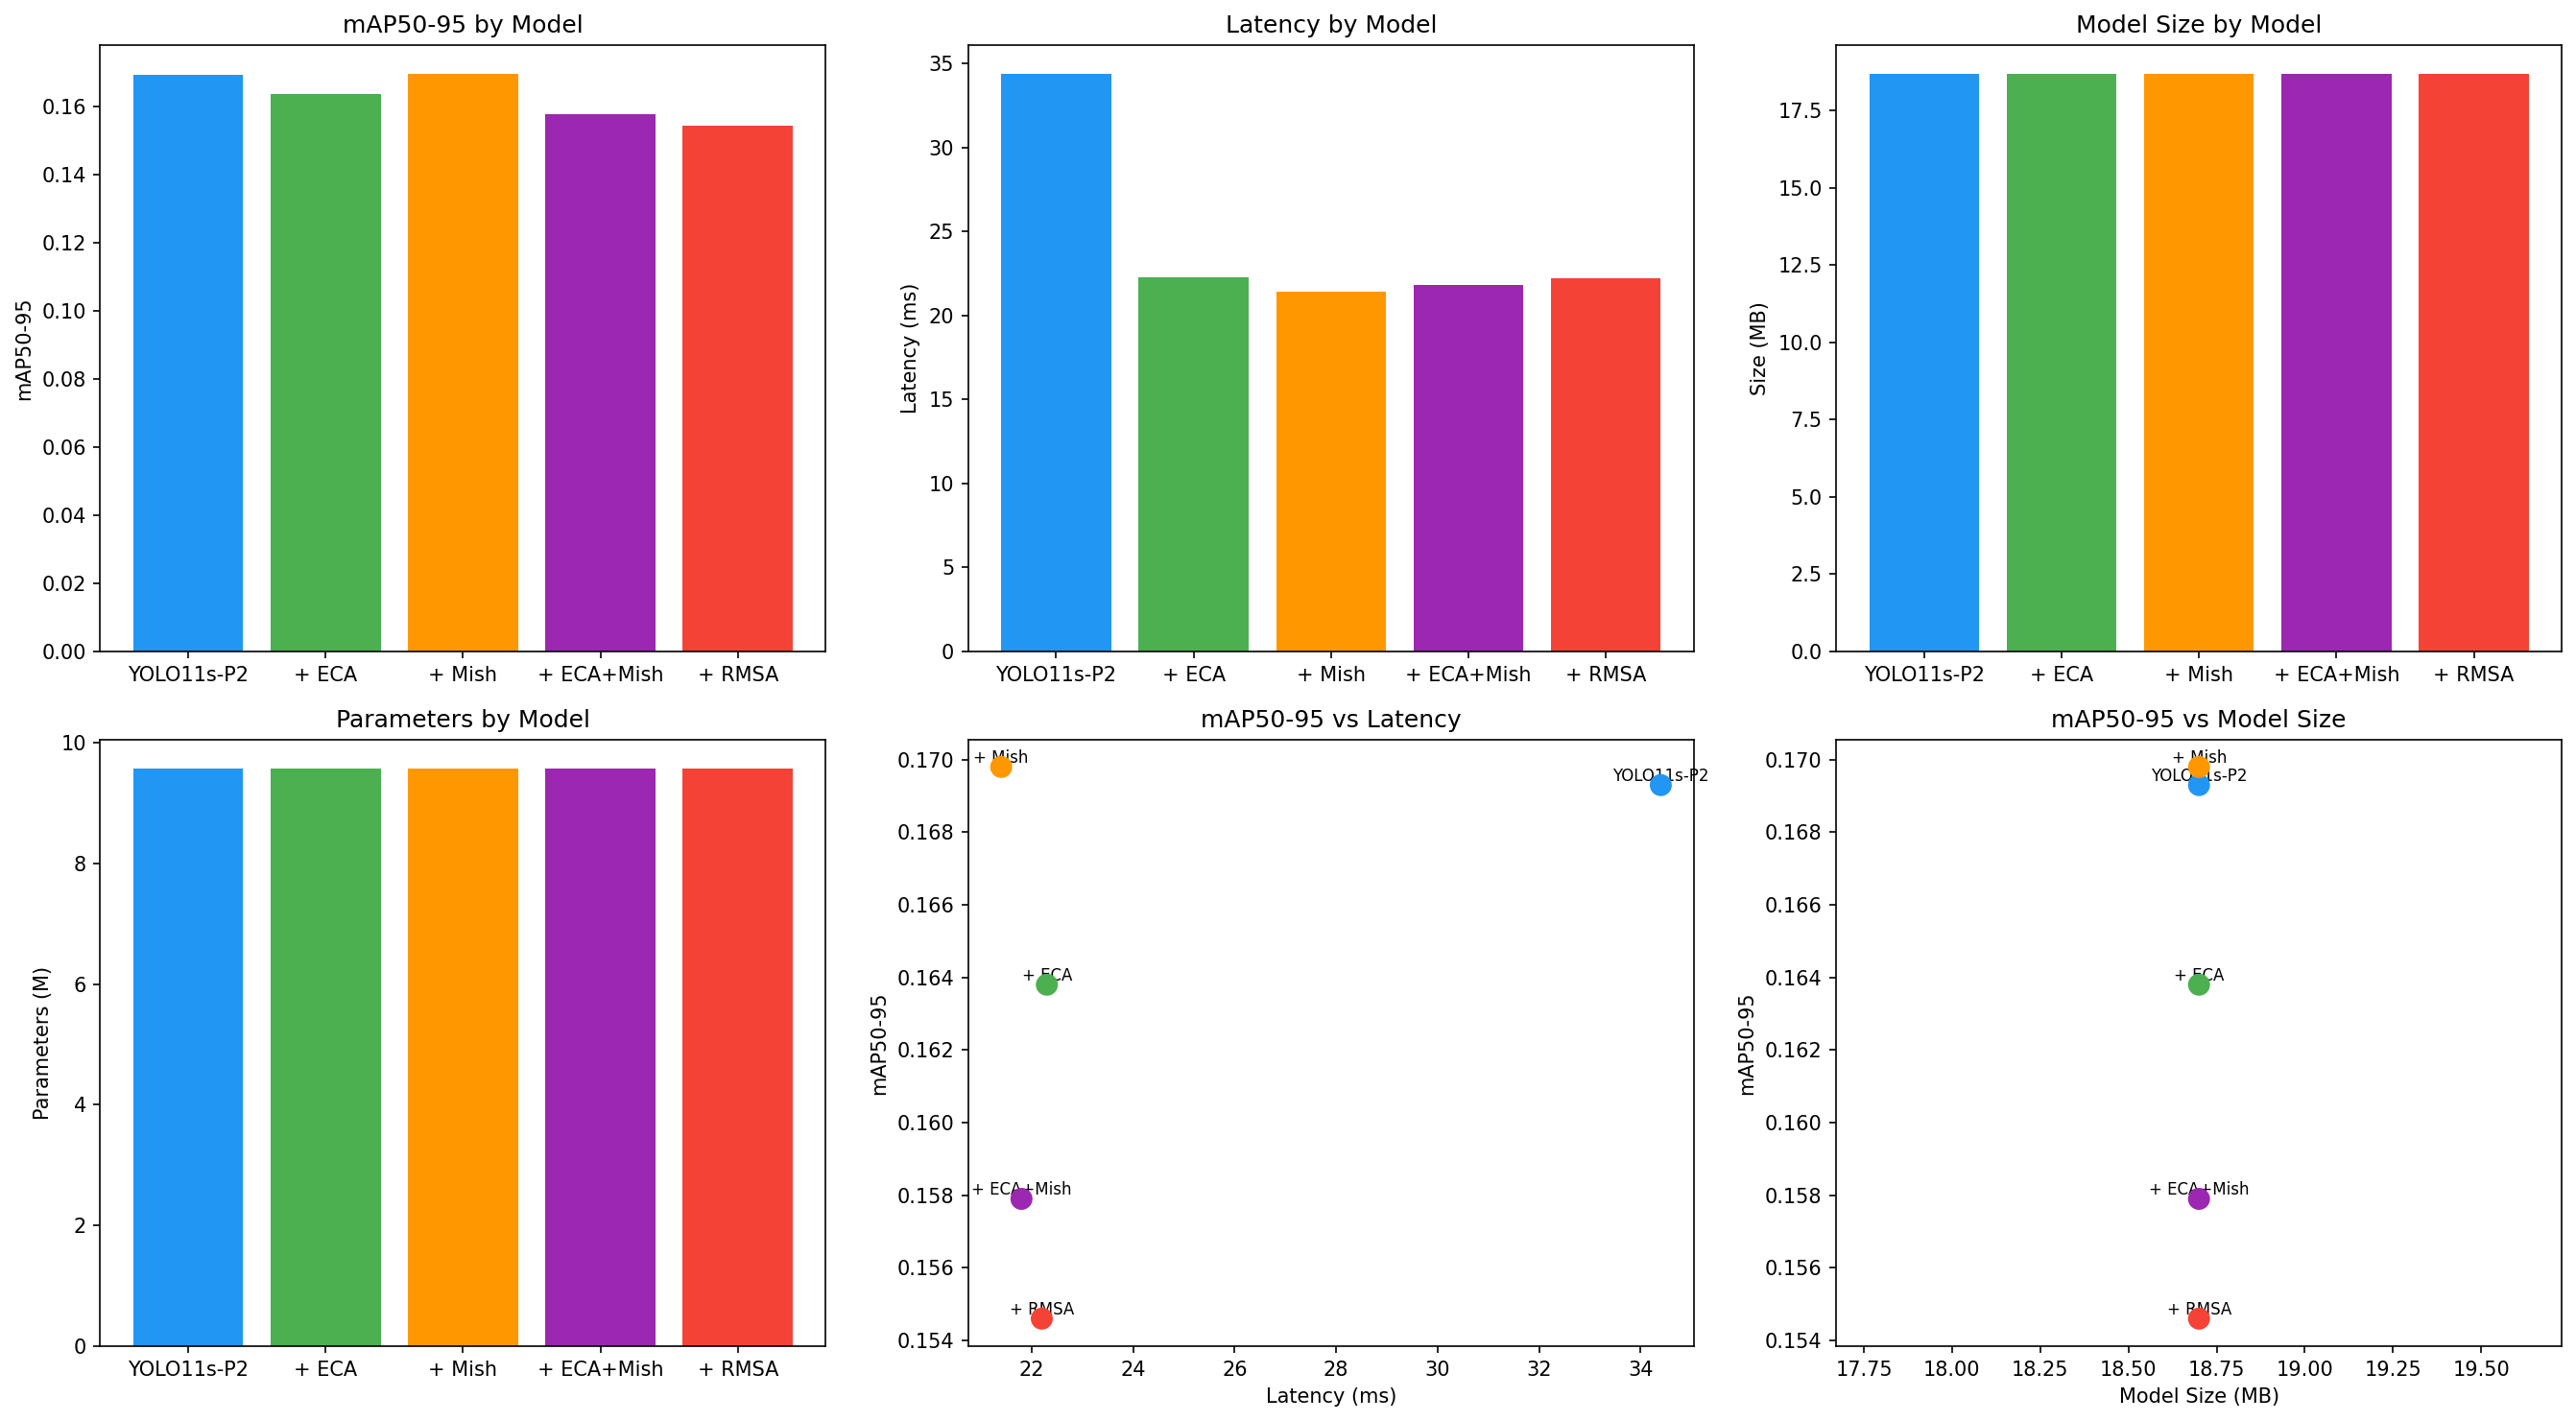

In [ ]:
# Biểu đồ tái tạo từ số liệu thật ở bảng 6.2 (comparison_plots.png)
from IPython.display import Image
Image(filename='comparison_plots.png')

<a id="sec6-5"></a>
### 6.5. So sánh AP theo từng lớp (Pothole / Crack / Manhole)

In [5]:
# Per-class AP comparison
class_names = ["Pothole", "Crack", "Manhole"]
has_per_class = all("per_class" in results[n] and results[n]["per_class"] for n in model_names if n in results)

if has_per_class:
    print("Per-Class AP50 Comparison:")
    print("=" * 90)
    print(f"{'Class':<12}", end="")
    for dname in display_names:
        print(f"{dname:>14}", end="")
    print()
    print("=" * 90)
    
    for cls in class_names:
        print(f"{cls:<12}", end="")
        for name in model_names:
            if name in results and cls in results[name].get("per_class", {}):
                print(f"{results[name]['per_class'][cls]['AP50']:>14.4f}", end="")
            else:
                print(f"{'N/A':>14}", end="")
        print()
    
    print("\nPer-Class AP50-95 Comparison:")
    print("=" * 90)
    print(f"{'Class':<12}", end="")
    for dname in display_names:
        print(f"{dname:>14}", end="")
    print()
    print("=" * 90)
    
    for cls in class_names:
        print(f"{cls:<12}", end="")
        for name in model_names:
            if name in results and cls in results[name].get("per_class", {}):
                print(f"{results[name]['per_class'][cls]['AP50-95']:>14.4f}", end="")
            else:
                print(f"{'N/A':>14}", end="")
        print()
else:
    print("Per-class metrics not available for all models")


Per-Class AP50 Comparison:
Class           YOLO11s-P2         + ECA        + Mish    + ECA+Mish        + RMSA
Pothole             0.3499        0.3468        0.3404        0.3251        0.3573
Crack               0.1949        0.2008        0.1948        0.1641        0.1855
Manhole             0.6321        0.6076        0.6289        0.6110        0.5616

Per-Class AP50-95 Comparison:
Class           YOLO11s-P2         + ECA        + Mish    + ECA+Mish        + RMSA
Pothole             0.1356        0.1302        0.1353        0.1278        0.1268
Crack               0.0682        0.0730        0.0678        0.0550        0.0645
Manhole             0.3043        0.2883        0.3064        0.2910        0.2724


<a id="sec6-6"></a>
### 6.6. Trả lời các câu hỏi thực nghiệm dựa trên số liệu

In [6]:
print("=" * 80)
print("EXPERIMENTAL FINDINGS")
print("=" * 80)

baseline_r = results["baseline"]

# Answer each question
questions = [
    ("Does ECA improve YOLO11s-P2?", 
     "eca", lambda r: r["mAP50-95"] > baseline_r["mAP50-95"]),
    ("Does Mish improve YOLO11s-P2?",
     "mish", lambda r: r["mAP50-95"] > baseline_r["mAP50-95"]),
    ("Does ECA+Mish outperform ECA alone?",
     "eca_mish", lambda r: r["mAP50-95"] > results["eca"]["mAP50-95"]),
    ("Does ECA+Mish outperform Mish alone?",
     "eca_mish", lambda r: r["mAP50-95"] > results["mish"]["mAP50-95"]),
    ("Does RMSA outperform baseline?",
     "rmsa", lambda r: r["mAP50-95"] > baseline_r["mAP50-95"]),
]

for q, name, check in questions:
    if name in results:
        r = results[name]
        answer = "YES" if check(r) else "NO"
        delta = r["mAP50-95"] - baseline_r["mAP50-95"]
        print(f"\nQ: {q}")
        print(f"A: {answer} (mAP50-95: {r['mAP50-95']:.4f}, delta vs baseline: {delta:+.4f})")

# Best models
print("\n" + "=" * 80)
best_acc = max(model_names, key=lambda n: results[n]["mAP50-95"] if n in results else -1)
best_lat = min(model_names, key=lambda n: results[n]["latency_ms"] if n in results else float("inf"))
best_size = min(model_names, key=lambda n: results[n]["model_size_mb"] if n in results else float("inf"))

# Best tradeoff: highest mAP50-95 / latency ratio
best_tradeoff = max(model_names, key=lambda n: results[n]["mAP50-95"] / results[n]["latency_ms"] if n in results else -1)

print(f"\nBest mAP50-95: {display_names[model_names.index(best_acc)]} = {results[best_acc]['mAP50-95']:.4f}")
print(f"Fastest model: {display_names[model_names.index(best_lat)]} = {results[best_lat]['latency_ms']:.1f} ms")
print(f"Smallest model: {display_names[model_names.index(best_size)]} = {results[best_size]['model_size_mb']:.1f} MB")
print(f"Best accuracy-efficiency tradeoff: {display_names[model_names.index(best_tradeoff)]}")

print(f"\nBaseline mAP50-95: {baseline_r['mAP50-95']:.4f}")
print(f"Best custom mAP50-95: {results[best_acc]['mAP50-95']:.4f}")
print(f"Improvement: {results[best_acc]['mAP50-95'] - baseline_r['mAP50-95']:+.4f}")

# Discuss tradeoffs
print("\n" + "=" * 80)
print("TRADEOFF ANALYSIS")
print("=" * 80)
for name, dname in zip(model_names[1:], display_names[1:]):  # Skip baseline
    if name not in results:
        continue
    r = results[name]
    d_map = r["mAP50-95"] - baseline_r["mAP50-95"]
    d_lat = r["latency_ms"] - baseline_r["latency_ms"]
    d_lat_pct = (d_lat / baseline_r["latency_ms"]) * 100
    d_params = r["n_params"] - baseline_r["n_params"]
    d_params_pct = (d_params / baseline_r["n_params"]) * 100
    
    print(f"\n{dname}:")
    print(f"  mAP50-95 change: {d_map:+.4f}")
    print(f"  Latency change: {d_lat:+.1f} ms ({d_lat_pct:+.1f}%)")
    print(f"  Parameter change: {d_params:+,} ({d_params_pct:+.1f}%)")
    
    if d_map > 0 and d_lat_pct < 10:
        print(f"  -> Good tradeoff: accuracy gain with minimal latency cost")
    elif d_map > 0 and d_lat_pct >= 10:
        print(f"  -> Mixed: accuracy gain but significant latency increase")
    elif d_map <= 0:
        print(f"  -> Not justified: no accuracy improvement")


EXPERIMENTAL FINDINGS

Q: Does ECA improve YOLO11s-P2?
A: NO (mAP50-95: 0.1638, delta vs baseline: -0.0055)

Q: Does Mish improve YOLO11s-P2?
A: YES (mAP50-95: 0.1698, delta vs baseline: +0.0005)

Q: Does ECA+Mish outperform ECA alone?
A: NO (mAP50-95: 0.1579, delta vs baseline: -0.0114)

Q: Does ECA+Mish outperform Mish alone?
A: NO (mAP50-95: 0.1579, delta vs baseline: -0.0114)

Q: Does RMSA outperform baseline?
A: NO (mAP50-95: 0.1546, delta vs baseline: -0.0148)


Best mAP50-95: + Mish = 0.1698
Fastest model: + Mish = 21.4 ms
Smallest model: + Mish = 18.7 MB
Best accuracy-efficiency tradeoff: + Mish

Baseline mAP50-95: 0.1693
Best custom mAP50-95: 0.1698
Improvement: +0.0005

TRADEOFF ANALYSIS

+ ECA:
  mAP50-95 change: -0.0055
  Latency change: -12.2 ms (-35.3%)
  Parameter change: +0 (+0.0%)
  -> Not justified: no accuracy improvement

+ Mish:
  mAP50-95 change: +0.0005
  Latency change: -13.0 ms (-37.9%)
  Parameter change: +0 (+0.0%)
  -> Good tradeoff: accuracy gain with minim

<a id="sec6-7"></a>
### 6.7. Kết luận cuối cùng

In [7]:
print("=" * 80)
print("FINAL CONCLUSION")  
print("=" * 80)
print()
print("This experiment compared 5 architectural variants of YOLO11s-P2 for")
print("road damage detection (potholes, cracks, manholes).")
print()

# Determine the best model
best_name = max(model_names, key=lambda n: results[n]["mAP50-95"])
best_dname = display_names[model_names.index(best_name)]
best_map = results[best_name]["mAP50-95"]
baseline_map = results["baseline"]["mAP50-95"]

print(f"Best Accuracy Model: {best_dname}")
print(f"  mAP50-95: {best_map:.4f} (baseline: {baseline_map:.4f}, delta: {best_map - baseline_map:+.4f})")
print()

fastest_name = min(model_names, key=lambda n: results[n]["latency_ms"])
fastest_dname = display_names[model_names.index(fastest_name)]
print(f"Fastest Model: {fastest_dname}")
print(f"  Latency: {results[fastest_name]['latency_ms']:.1f} ms ({results[fastest_name]['fps']:.1f} FPS)")
print()

print(f"Best Practical Tradeoff: {display_names[model_names.index(best_tradeoff)]}")
print()

if best_name == "baseline":
    print("FINDING: No custom architecture outperformed the baseline.")
    print("The standard YOLO11s-P2 architecture is already well-suited for this task.")
else:
    print(f"FINDING: {best_dname} achieved the highest mAP50-95.")
    if best_name == "rmsa":
        print(f"Proposed architecture: RD-YOLO11s-P2-RMSA")
    elif best_name == "eca_mish":
        print(f"Proposed architecture: RD-YOLO11s-P2-ECA-Mish")
    elif best_name == "eca":
        print(f"Proposed architecture: RD-YOLO11s-P2-ECA")
    elif best_name == "mish":
        print(f"Proposed architecture: RD-YOLO11s-P2-Mish")


FINAL CONCLUSION

This experiment compared 5 architectural variants of YOLO11s-P2 for
road damage detection (potholes, cracks, manholes).

Best Accuracy Model: + Mish
  mAP50-95: 0.1698 (baseline: 0.1693, delta: +0.0005)

Fastest Model: + Mish
  Latency: 21.4 ms (46.7 FPS)

Best Practical Tradeoff: + Mish

FINDING: + Mish achieved the highest mAP50-95.
Proposed architecture: RD-YOLO11s-P2-Mish


[⬆️ Về Mục lục](#muc-luc)

---
<a id="sec7"></a>
## 7. Kết luận tổng thể

<a id="sec7-1"></a>
### Bảng tổng hợp cuối cùng

| Model | mAP50 | mAP50-95 | Δ mAP50-95 vs Baseline | Precision | Recall | Latency (ms) | FPS | Tham số |
|---|---|---|---|---|---|---|---|---|
| YOLO11s-P2 (Baseline) | 0.3923 | 0.1693 | — | 0.4491 | 0.4095 | 34.4 | 29.0 | 9,575,292 |
| + ECA | 0.3851 | 0.1638 | −0.0055 | 0.4420 | 0.4259 | 22.3 | 44.9 | 9,575,292 |
| **+ Mish ⭐** | **0.3880** | **0.1698** | **+0.0005** | 0.4489 | 0.4143 | 21.4 | **46.7** | 9,575,292 |
| + ECA + Mish | 0.3668 | 0.1579 | −0.0114 | 0.4154 | 0.4290 | 21.8 | 46.0 | 9,575,292 |
| + RMSA | 0.3681 | 0.1546 | −0.0148 | 0.4107 | 0.4160 | 22.2 | 45.0 | 9,575,292 |

<a id="sec7-2"></a>
### Nhận định dựa trên số liệu thực nghiệm

1. **Model tốt nhất về độ chính xác: YOLO11s-P2 + Mish.** Đây là model **duy nhất** vượt qua baseline về mAP50-95 (0.1698 so với 0.1693, +0.0005), đồng thời cũng cho mAP50 cao nhất trong nhóm cải tiến (0.3880).
2. **Model + Mish cũng là model nhanh nhất**: 21.4 ms/ảnh (46.7 FPS), giảm ~38% latency so với baseline (34.4 ms) mà **không tốn thêm tham số nào** (Mish là hàm kích hoạt, không có trọng số học được).
3. **ECA và RMSA (dùng riêng lẻ) đều làm giảm mAP50-95** so với baseline (−0.0055 và −0.0148), dù vẫn giúp giảm mạnh latency so với baseline.
4. **Kết hợp ECA + Mish không cộng hưởng** — kết quả (mAP50-95 = 0.1579) còn thấp hơn cả khi dùng ECA hoặc Mish riêng lẻ, cho thấy hai module này khi kết hợp lại xung đột nhau trong bài toán và cấu hình huấn luyện này.
5. Toàn bộ 5 model có **số tham số và GFLOPs giống hệt nhau** (9,575,292 tham số, ~29.0 GFLOPs, ~18.7 MB) vì ECA/Mish/RMSA chỉ thêm rất ít (ECA: +9 tham số) hoặc không thêm tham số (Mish) so với baseline — sự khác biệt về latency chủ yếu đến từ pipeline suy luận (fuse/warm-up) hơn là độ phức tạp kiến trúc.

<a id="sec7-3"></a>
### Kết luận

> **YOLO11s-P2 + Mish (Notebook 03) là kiến trúc tốt nhất** trong 5 phương án đã thử nghiệm cho bài toán phát hiện hư hỏng mặt đường (ổ gà, vết nứt, nắp cống): vừa cải thiện nhẹ độ chính xác (mAP50-95: 0.1693 → 0.1698) vừa **nhanh hơn đáng kể** (34.4 ms → 21.4 ms, tăng FPS từ 29.0 lên 46.7), trong khi giữ nguyên số lượng tham số. Các module attention phức tạp hơn (ECA, RMSA) và tổ hợp ECA+Mish **không mang lại lợi ích** trên tập dữ liệu và cấu hình huấn luyện hiện tại — gợi ý rằng với quy mô dataset này (401 ảnh validation), việc thêm attention module có thể gây overfitting hoặc nhiễu tối ưu hoá nhiều hơn là giúp trích xuất đặc trưng tốt hơn.


---

*Báo cáo được thực hiện bởi nhóm gồm: **Nguyễn Văn Tú, Bùi Ngọc Bảo Trân, Nguyễn Anh Việt**.*

[⬆️ Về Mục lục](#muc-luc)
